In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as stats
from matplotlib import pyplot as plt

In [ ]:
df = pd.read_csv('../data/short_ships(in with date).csv')
df = df[df["SHIPS_TIME"] <= 36]
df = df[df["SHIPS_TIME"] >= 0]
df[["SHIPS_stormbasin", "SHIPS_stormid"]].groupby("SHIPS_stormid").first().value_counts()

SHIPS_stormbasin
EP                  749
AL                  610
CP                   57
Name: count, dtype: int64

: 

: 

In [ ]:
df

,SHIPS_case,SHIPS_time,SHIPS_VMAX,SHIPS_stormyear,SHIPS_stormbasin,SHIPS_stormid,SHIPS_TIME,SHIPS_MSLP,SHIPS_LAT,SHIPS_LON,SHIPS_VMPI,SHIPS_yyyymmddhhmm
2,0,0 days 00:00:00,20.0,1982,AL,AL011982,0,1005.0,21.7,-87.1,123.0,1.982060e+11
3,0,0 days 06:00:00,25.0,1982,AL,AL011982,6,1004.0,22.0,-86.3,122.0,1.982060e+11
4,0,0 days 12:00:00,30.0,1982,AL,AL011982,12,1003.0,22.3,-85.6,117.0,1.982060e+11
5,0,0 days 18:00:00,40.0,1982,AL,AL011982,18,1001.0,22.3,-84.9,117.0,1.982060e+11
6,0,1 days 00:00:00,50.0,1982,AL,AL011982,24,995.0,22.7,-83.9,121.0,1.982060e+11
...,...,...,...,...,...,...,...,...,...,...,...,...
992066,32002,0 days 12:00:00,NaN,2019,CP,CP012019,12,NaN,NaN,NaN,NaN,2.019100e+11
992067,32002,0 days 18:00:00,NaN,2019,CP,CP012019,18,NaN,NaN,NaN,NaN,2.019100e+11
992068,32002,1 days 00:00:00,NaN,2019,CP,CP012019,24,NaN,NaN,NaN,NaN,2.019100e+11
992069,32002,1 days 06:00:00,NaN,2019,CP,CP012019,30,NaN,NaN,NaN,NaN,2.019100e+11


: 

: 

In [ ]:
# find vmax over the first 12 hours for each storm case
VMAX12_df = df[df["SHIPS_TIME"] <= 12][["SHIPS_case", "SHIPS_VMAX"]].groupby("SHIPS_case").max(min_count=3).rename(columns={"SHIPS_VMAX": "VMAX12"})
VMAX12_df

,VMAX12
SHIPS_case,
0,30.0
1,40.0
2,50.0
3,75.0
4,75.0
...,...
31998,40.0
31999,35.0
32000,35.0


: 

: 

In [ ]:
MSLP12_df = df[df["SHIPS_TIME"] <= 12][["SHIPS_case", "SHIPS_MSLP"]].groupby("SHIPS_case").min(min_count=3).rename(columns={"SHIPS_MSLP": "MSLP12"})
MSLP12_df

,MSLP12
SHIPS_case,
0,1003.0
1,1001.0
2,995.0
3,985.0
4,985.0
...,...
31998,1005.0
31999,1006.0
32000,1006.0


: 

: 

In [ ]:
POT_df = df[df["SHIPS_TIME"] == 12][["SHIPS_case", "SHIPS_VMPI", "SHIPS_VMAX"]]
POT_df["POT12"] = POT_df["SHIPS_VMPI"] - POT_df["SHIPS_VMAX"]
POT_df["VMPI12"] = POT_df["SHIPS_VMPI"]
POT_df = POT_df[["SHIPS_case", "POT12", "VMPI12"]].set_index("SHIPS_case")
POT_df

,POT12,VMPI12
SHIPS_case,,
0,87.0,117.0
1,77.0,117.0
2,71.0,121.0
3,30.0,105.0
4,35.0,100.0
...,...,...
31998,104.0,139.0
31999,111.0,141.0
32000,105.0,135.0


: 

: 

In [ ]:
VMAX36_df = df[df["SHIPS_TIME"] > 12][["SHIPS_case", "SHIPS_VMAX"]].groupby("SHIPS_case").max(min_count=4).rename(columns={"SHIPS_VMAX": "VMAX36"})
VMAX36_df

,VMAX36
SHIPS_case,
0,75.0
1,75.0
2,75.0
3,65.0
4,55.0
...,...
31998,NaN
31999,NaN
32000,NaN


: 

: 

In [ ]:
V12_df = df[df["SHIPS_TIME"] == 12][["SHIPS_case", "SHIPS_VMAX"]].groupby("SHIPS_case").first()
V6_df = df[df["SHIPS_TIME"] == 6][["SHIPS_case", "SHIPS_VMAX"]].groupby("SHIPS_case").first()
V0_df = df[df["SHIPS_TIME"] == 0][["SHIPS_case", "SHIPS_VMAX"]].groupby("SHIPS_case").first()

VGRAD_df = V6_df.join(V12_df, on="SHIPS_case", lsuffix="6", rsuffix="12").join(V0_df, on="SHIPS_case").rename(columns={"SHIPS_VMAX": "SHIPS_VMAX0"})
VGRAD_df["VGRAD0-6"] = (VGRAD_df["SHIPS_VMAX6"] - VGRAD_df["SHIPS_VMAX0"]) / 6
VGRAD_df["VGRAD6-12"] = (VGRAD_df["SHIPS_VMAX12"] - VGRAD_df["SHIPS_VMAX6"]) / 6
VGRAD_df["VlogGRAD6-12"] = np.log(VGRAD_df["SHIPS_VMAX12"]) - np.log(VGRAD_df["SHIPS_VMAX6"])

VGRAD_df
VGRAD_df.drop(axis=1, labels=["SHIPS_VMAX12", "SHIPS_VMAX6", "SHIPS_VMAX0"], inplace=True)

: 

: 

In [ ]:
''.join(list(str(1.982060e+11))[4:6])

'06'

: 

: 

In [ ]:
cases = df[["SHIPS_case", "SHIPS_stormyear", "SHIPS_stormbasin", "SHIPS_stormid", "SHIPS_yyyymmddhhmm", "SHIPS_LAT", "SHIPS_LON"]].groupby("SHIPS_case").first().rename(columns={"SHIPS_case": "SHIPS_case", "SHIPS_stormyear": "Year", "SHIPS_stormbasin": "Basin", "SHIPS_stormid": "StormID", "SHIPS_LAT": "LAT", "SHIPS_LON": "LON"})
print(cases.columns)
cases["month"] = 0
for i in range(len(cases)):
    cases.at[i, "month"] = ''.join(list(str(cases.iloc[i]["SHIPS_yyyymmddhhmm"]))[4:6])
cases["day"] = 1
cases["Date"] = pd.to_datetime(cases[["month", "Year", "day"]])
cases.drop(columns=["month", "Year", "day", "SHIPS_yyyymmddhhmm"], inplace=True)
one_hot_basins = pd.get_dummies(cases["Basin"], dtype=float)
cases = cases.join(one_hot_basins)

Index(['Year', 'Basin', 'StormID', 'SHIPS_yyyymmddhhmm', 'LAT', 'LON'], dtype='object')


/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_53240/2191191698.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '06' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cases.at[i, "month"] = ''.join(list(str(cases.iloc[i]["SHIPS_yyyymmddhhmm"]))[4:6])


: 

: 

In [ ]:
data = cases.join(VMAX12_df, on="SHIPS_case").join(MSLP12_df, on="SHIPS_case").join(POT_df, on="SHIPS_case").join(VGRAD_df, on="SHIPS_case").join(VMAX36_df, on="SHIPS_case")
data = data.groupby("StormID").first().dropna()
print(data["Basin"].value_counts())
data.columns
data

Basin
EP    555
AL    548
CP     23
Name: count, dtype: int64


,Basin,LAT,LON,Date,AL,CP,EP,VMAX12,MSLP12,POT12,VMPI12,VGRAD0-6,VGRAD6-12,VlogGRAD6-12,VMAX36
StormID,,,,,,,,,,,,,,,
AL011982,AL,21.7,-87.1,1982-06-01,1.0,0.0,0.0,30.0,1003.0,87.0,117.0,0.833333,0.833333,0.182322,75.0
AL011985,AL,29.4,-64.2,1985-07-01,1.0,0.0,0.0,30.0,1011.0,89.0,119.0,0.000000,0.000000,0.000000,40.0
AL011986,AL,26.2,-75.8,1986-06-01,1.0,0.0,0.0,30.0,1005.0,72.0,102.0,0.000000,0.000000,0.000000,45.0
AL011988,AL,32.0,-77.5,1988-08-01,1.0,0.0,0.0,20.0,1013.0,106.0,126.0,0.000000,0.000000,0.000000,30.0
AL011991,AL,31.3,-79.7,1991-07-01,1.0,0.0,0.0,25.0,1010.0,85.0,110.0,0.000000,0.000000,0.000000,45.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EP241992,EP,11.0,-97.0,1992-10-01,0.0,0.0,1.0,30.0,1007.0,118.0,148.0,0.833333,0.000000,0.000000,50.0
EP242018,EP,14.8,-103.6,2018-10-01,0.0,0.0,1.0,35.0,1005.0,136.0,171.0,0.000000,0.833333,0.154151,85.0
EP252018,EP,14.2,-109.9,2018-11-01,0.0,0.0,1.0,35.0,1006.0,130.0,165.0,0.000000,0.833333,0.154151,50.0


: 

: 

In [ ]:
oni = pd.read_csv("../data/oni.csv")
oni.rename(columns={"  ONI from CPC  missing value -99.9 https://psl.noaa.gov/data/timeseries/month/": "ONI"}, inplace=True)
oni = oni[pd.to_datetime(oni["Date"]) <= pd.to_datetime("01-01-2023")]
oni = oni[pd.to_datetime(oni["Date"]) >= pd.to_datetime("01-01-1981")]
oni["Date"] = pd.to_datetime(oni["Date"])
data["Date"] = pd.to_datetime(data["Date"])
oni.set_index("Date", inplace=True)
data.set_index("Date", inplace=True)
data = data.join(oni, how="left")
data

,Basin,LAT,LON,AL,CP,EP,VMAX12,MSLP12,POT12,VMPI12,VGRAD0-6,VGRAD6-12,VlogGRAD6-12,VMAX36,ONI
Date,,,,,,,,,,,,,,,
1982-06-01,AL,21.7,-87.1,1.0,0.0,0.0,30.0,1003.0,87.0,117.0,0.833333,0.833333,0.182322,75.0,0.72
1985-07-01,AL,29.4,-64.2,1.0,0.0,0.0,30.0,1011.0,89.0,119.0,0.000000,0.000000,0.000000,40.0,-0.49
1986-06-01,AL,26.2,-75.8,1.0,0.0,0.0,30.0,1005.0,72.0,102.0,0.000000,0.000000,0.000000,45.0,-0.04
1988-08-01,AL,32.0,-77.5,1.0,0.0,0.0,20.0,1013.0,106.0,126.0,0.000000,0.000000,0.000000,30.0,-1.11
1991-07-01,AL,31.3,-79.7,1.0,0.0,0.0,25.0,1010.0,85.0,110.0,0.000000,0.000000,0.000000,45.0,0.73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1992-10-01,EP,11.0,-97.0,0.0,0.0,1.0,30.0,1007.0,118.0,148.0,0.833333,0.000000,0.000000,50.0,-0.25
2018-10-01,EP,14.8,-103.6,0.0,0.0,1.0,35.0,1005.0,136.0,171.0,0.000000,0.833333,0.154151,85.0,0.81
2018-11-01,EP,14.2,-109.9,0.0,0.0,1.0,35.0,1006.0,130.0,165.0,0.000000,0.833333,0.154151,50.0,0.97


: 

: 

In [ ]:
cols_to_log = ['VMAX12', 'MSLP12', 'POT12', 'VMAX36', 'VMPI12']
for col in cols_to_log:
    data[f"log{col}"] = np.log(data[col])
data

,Basin,LAT,LON,AL,CP,EP,VMAX12,MSLP12,POT12,VMPI12,VGRAD0-6,VGRAD6-12,VlogGRAD6-12,VMAX36,ONI,logVMAX12,logMSLP12,logPOT12,logVMAX36,logVMPI12
Date,,,,,,,,,,,,,,,,,,,,
1982-06-01,AL,21.7,-87.1,1.0,0.0,0.0,30.0,1003.0,87.0,117.0,0.833333,0.833333,0.182322,75.0,0.72,3.401197,6.910751,4.465908,4.317488,4.762174
1985-07-01,AL,29.4,-64.2,1.0,0.0,0.0,30.0,1011.0,89.0,119.0,0.000000,0.000000,0.000000,40.0,-0.49,3.401197,6.918695,4.488636,3.688879,4.779123
1986-06-01,AL,26.2,-75.8,1.0,0.0,0.0,30.0,1005.0,72.0,102.0,0.000000,0.000000,0.000000,45.0,-0.04,3.401197,6.912743,4.276666,3.806662,4.624973
1988-08-01,AL,32.0,-77.5,1.0,0.0,0.0,20.0,1013.0,106.0,126.0,0.000000,0.000000,0.000000,30.0,-1.11,2.995732,6.920672,4.663439,3.401197,4.836282
1991-07-01,AL,31.3,-79.7,1.0,0.0,0.0,25.0,1010.0,85.0,110.0,0.000000,0.000000,0.000000,45.0,0.73,3.218876,6.917706,4.442651,3.806662,4.700480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1992-10-01,EP,11.0,-97.0,0.0,0.0,1.0,30.0,1007.0,118.0,148.0,0.833333,0.000000,0.000000,50.0,-0.25,3.401197,6.914731,4.770685,3.912023,4.997212
2018-10-01,EP,14.8,-103.6,0.0,0.0,1.0,35.0,1005.0,136.0,171.0,0.000000,0.833333,0.154151,85.0,0.81,3.555348,6.912743,4.912655,4.442651,5.141664
2018-11-01,EP,14.2,-109.9,0.0,0.0,1.0,35.0,1006.0,130.0,165.0,0.000000,0.833333,0.154151,50.0,0.97,3.555348,6.913737,4.867534,3.912023,5.105945


: 

: 

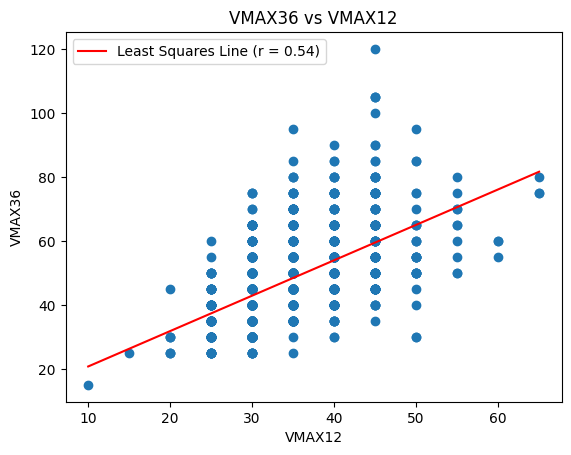

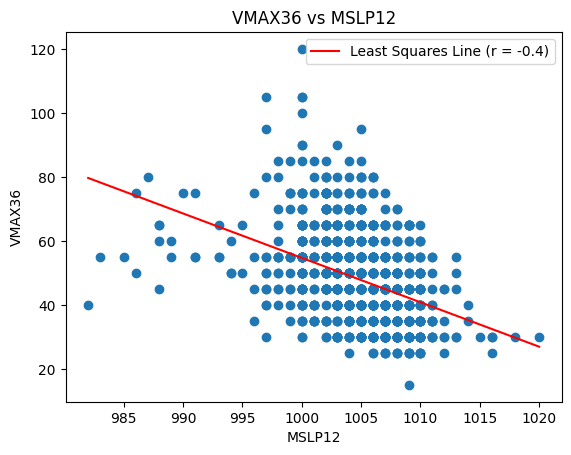

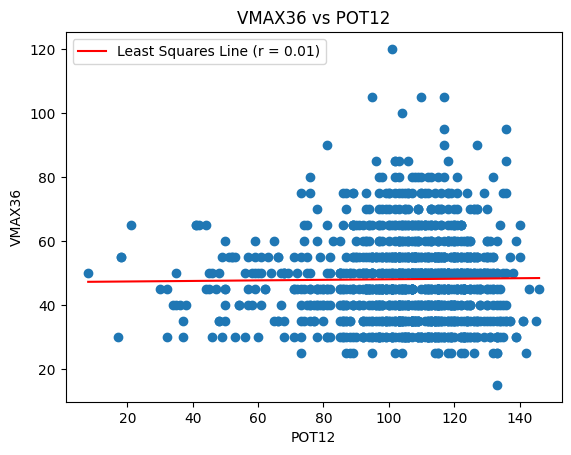

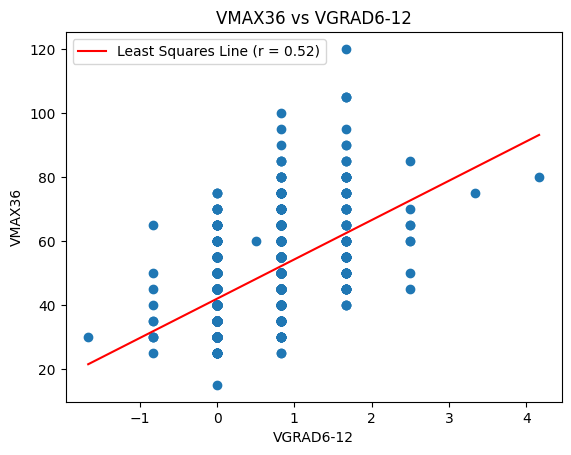

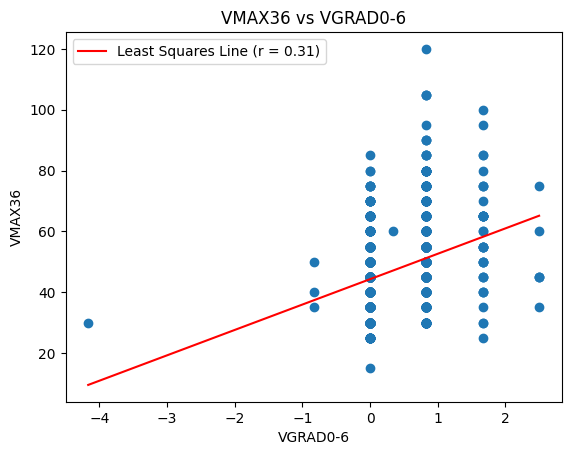

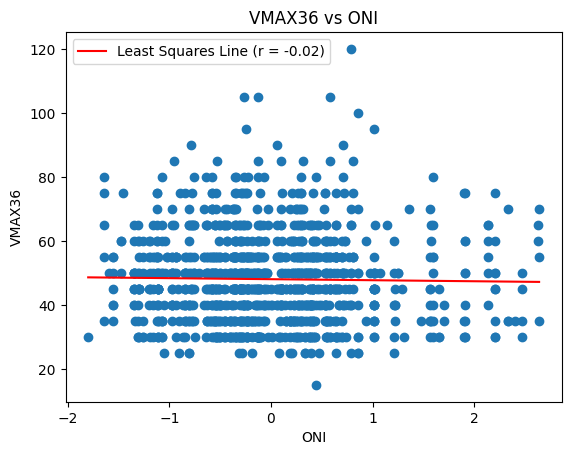

1126

: 

: 

In [ ]:
cols_to_test = ['VMAX12', 'MSLP12', 'POT12', 'VGRAD6-12', 'VGRAD0-6', 'ONI']
for col in cols_to_test:
    reg = stats.linregress(data[col], data["VMAX36"])
    domain = np.linspace(min(data[col]), max(data[col]), 200)
    plt.title(f"VMAX36 vs {col}")
    plt.xlabel(col)
    plt.ylabel("VMAX36")
    plt.plot(domain, reg[0]*domain + reg[1], color='red', label=f'Least Squares Line (r = {np.round(reg[2], 2)})')
    plt.scatter(data[col], data["VMAX36"])
    plt.legend()
    plt.show()
len(data)

In [ ]:
len(data)

1126

: 

: 

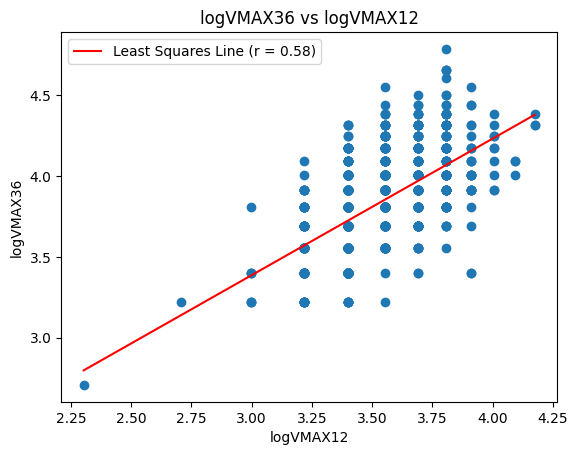

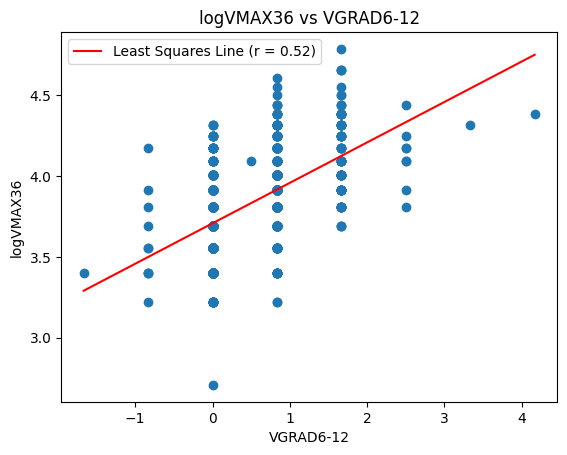

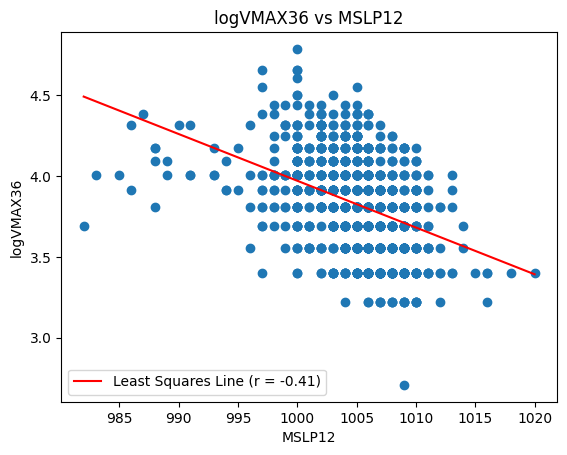

: 

: 

In [ ]:
cols_to_test2 = ['logVMAX12', "VGRAD6-12", "MSLP12"]
for col in cols_to_test2:
    reg = stats.linregress(data[col], data["logVMAX36"])
    domain = np.linspace(min(data[col]), max(data[col]), 200)
    plt.title(f"logVMAX36 vs {col}")
    plt.xlabel(col)
    plt.ylabel("logVMAX36")
    plt.plot(domain, reg[0]*domain + reg[1], color='red', label=f'Least Squares Line (r = {np.round(reg[2], 2)})')
    plt.scatter(data[col], data["logVMAX36"])
    plt.legend()
    plt.savefig(f"../images/{col}_vs_logVMAX36.png")
    plt.show()

In [ ]:
min(data["logVMAX36"])
np.std(data["logVMAX36"])

np.float64(0.28071399978490486)

: 

: 

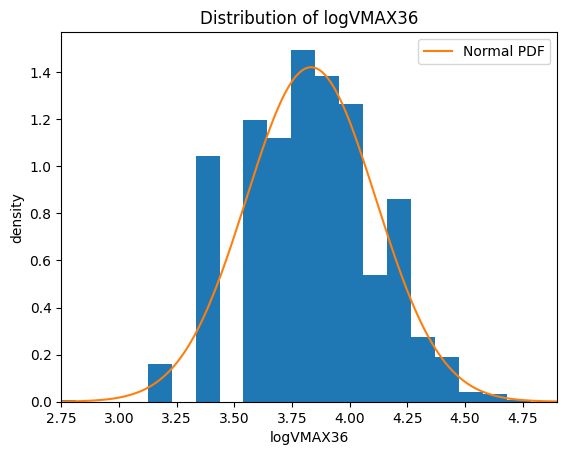

: 

: 

In [ ]:
plt.hist(data["logVMAX36"], bins=20, density=True)
plt.title("Distribution of logVMAX36")
plt.xlabel("logVMAX36")
plt.ylabel("density")
domain = np.linspace(2.5, 5, 200)
plt.plot(domain, stats.norm.pdf(domain, np.mean(data["logVMAX36"]), np.std(data["logVMAX36"], ddof=1)), label='Normal PDF')
plt.xlim([2.75, 4.9])
plt.legend()
plt.savefig("../images/log_vmax36_dist.png")
plt.show()

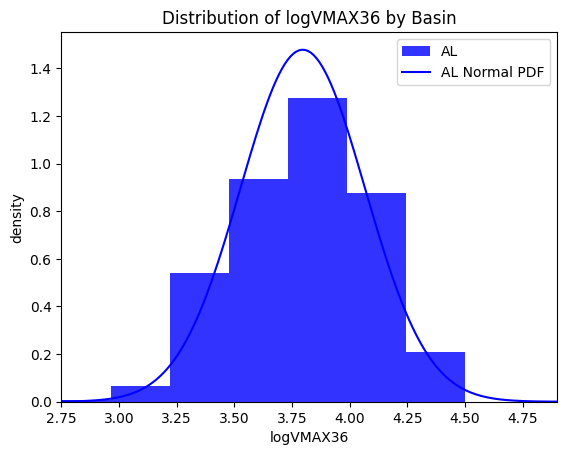

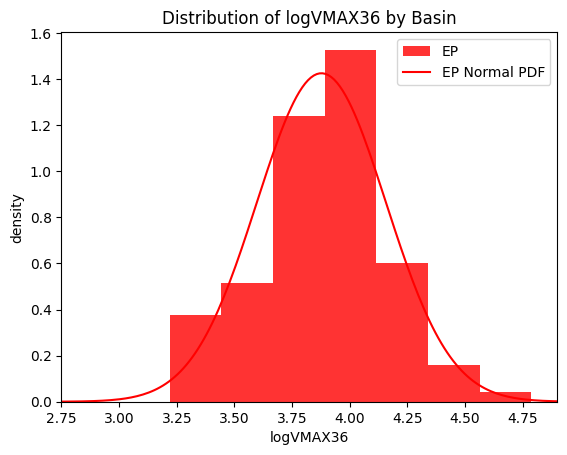

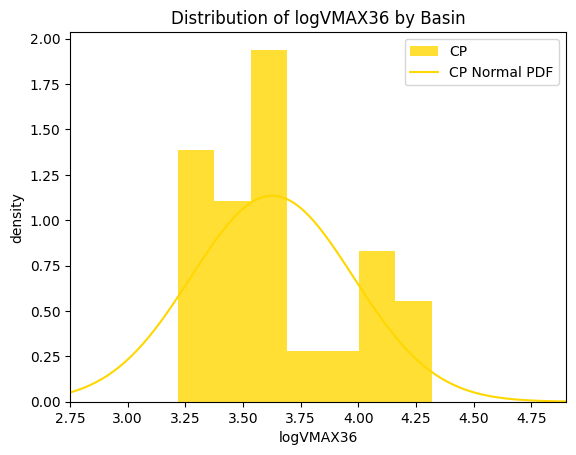

: 

: 

In [ ]:
basins = ["AL", "EP", "CP"]
colors = ["blue", "red", "gold"]
color_dict = {}
for i in range(3):
    color_dict[basins[i]] = colors[i]
for basin in basins:
    basin_df = data[data["Basin"] == basin]
    plt.hist(basin_df["logVMAX36"], bins=7, density=True, label=basin, alpha=0.8, color=color_dict[basin])
    plt.title("Distribution of logVMAX36 by Basin")
    plt.xlabel("logVMAX36")
    plt.ylabel("density")
    domain = np.linspace(2.5, 5, 200)
    plt.plot(domain, stats.norm.pdf(domain, np.mean(basin_df["logVMAX36"]), np.std(basin_df["logVMAX36"], ddof=1)), label=f'{basin} Normal PDF', color=color_dict[basin])
    plt.xlim([2.75, 4.9])
    plt.legend()
    plt.savefig(f"../images/{basin}_log_vmax36_dist.png")
    plt.show()

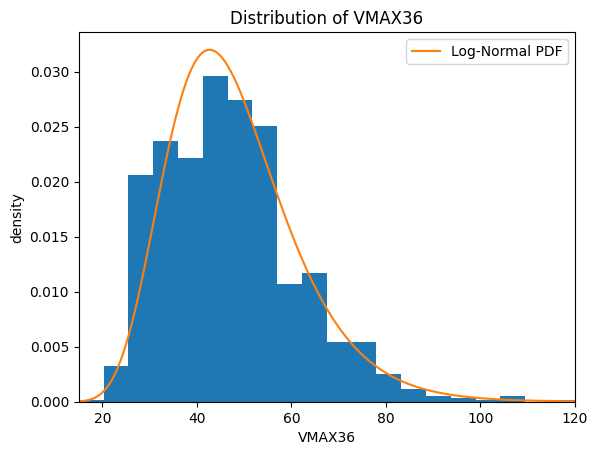

: 

: 

In [ ]:
plt.hist(data["VMAX36"], bins=20, density=True)
plt.title("Distribution of VMAX36")
plt.xlabel("VMAX36")
plt.ylabel("density")
domain = np.linspace(13, 125, 200)
plt.plot(domain, stats.lognorm.pdf(domain, np.std(data["logVMAX36"], ddof=1), scale=np.exp(np.mean(data["logVMAX36"]))), label='Log-Normal PDF')
plt.xlim([15, 120])
plt.legend()
plt.savefig('../images/vmax36_dist.png')
plt.show()

In [ ]:
basins = ["AL", "EP", "CP"]
colors = ["blue", "red", "gold"]
color_dict = {}
for i in range(3):
    color_dict[basins[i]] = colors[i]
plt.title("Distribution of VMAX36 by Basin")
for i in range(3):
    basin = basins[i]
    basin_df = data[data["Basin"] == basin]
    plt.subplot(i, 1, 3)
    plt.hist(basin_df["VMAX36"], bins=12, density=True, label=basin, alpha=0.8, color=color_dict[basin])
    plt.xlabel("logVMAX36")
    plt.ylabel("density")
    domain = np.linspace(2.5, 5, 200)
    plt.plot(domain, stats.norm.pdf(domain, np.mean(basin_df["logVMAX36"]), np.std(basin_df["logVMAX36"], ddof=1)), label=f'{basin} Normal PDF', color=color_dict[basin])
    plt.xlim([2.75, 4.9])
    plt.legend()
plt.savefig(f"../images/basin_separated_log_vmax36_dist.png")
plt.show()

NameError: name 'plt' is not defined

: 

: 

In [ ]:
data_final = data.drop(axis=1, labels=["VlogGRAD6-12"])
data_final.to_csv("../processed_data/processed_data.csv")

: 

: 

In [ ]:
data_final["Basin"].value_counts()

Basin
EP    555
AL    548
CP     23
Name: count, dtype: int64

: 

: 